<a href="https://colab.research.google.com/github/fhassan711/DeepLearning-Tutorial1/blob/main/DeepLearning_Tutorial_5_CNN_Updated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Understanding of Part 1**

Tutorial 5 teaches how to build, train, evaluate and visualize a Convolutional Neural Network (CNN) that classifies the CIFAR-10 images into 10 classes, using TensorFlow/Keras. The "Additional Notes" section is a hand-worked example of the convolution → ReLU → pooling → fully connected → backpropagation maths. It contains no code to run.

One note on extraction: the code in your PDF is a screenshot (there is no copyable text), so I transcribed it from the images. It is faithful to what is visible, but please compare spacing and comments against your original.

**Step 1: Import Libraries**

In [1]:
import tensorflow as tf  # For building and training the CNN
from tensorflow.keras import layers, models  # For creating layers and models
import matplotlib.pyplot as plt  # For plotting images and accuracy/loss graphs
import numpy as np  # For numerical operations

**Step 2: Load and Preprocess the CIFAR-10 Dataset**

In [2]:
# Load the CIFAR-10 dataset from TensorFlow datasets
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.cifar10.load_data()

# Normalize the pixel values from range [0, 255] to [0, 1]
train_images = train_images / 255.0
test_images = test_images / 255.0

# Class names for CIFAR-10
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 559s 3us/step


**Step 3: Visualize Some Data**

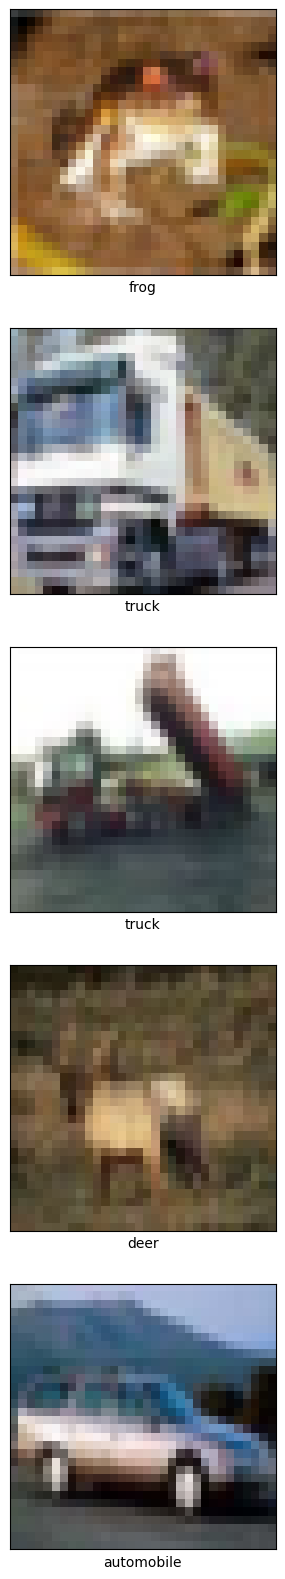

In [3]:
# Plot the first 5 images from the training set along with their labels
plt.figure(figsize=(10, 20))
for i in range(5):
    plt.subplot(5, 1, i + 1)
    plt.xticks([])  # Remove x-axis ticks
    plt.yticks([])  # Remove y-axis ticks
    plt.grid(False)  # Disable grid
    plt.imshow(train_images[i])  # Show the image
    plt.xlabel(class_names[train_labels[i][0]])  # Label with class name
plt.show()

**Step 4: Build the CNN**

In [4]:
# Build the CNN model
model = models.Sequential([
    # First Convolutional Layer with 32 filters, a 3x3 kernel, and ReLU activation
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    # Max Pooling Layer with a 2x2 pool size
    layers.MaxPooling2D((2, 2)),

    # Second Convolutional Layer with 64 filters and ReLU activation
    layers.Conv2D(64, (3, 3), activation='relu'),
    # Max Pooling Layer
    layers.MaxPooling2D((2, 2)),

    # Third Convolutional Layer with 64 filters and ReLU activation
    layers.Conv2D(64, (3, 3), activation='relu'),

    # Flatten the output to feed it into fully connected layers
    layers.Flatten(),
    # Fully connected layer with 64 neurons and ReLU activation
    layers.Dense(64, activation='relu'),
    # Output layer with 10 neurons (one for each class) and softmax activation for classification
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


**Step 5: Compile the Model**

In [5]:
# Compile the model using Adam optimizer and sparse categorical crossentropy as the loss function
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Display the model architecture summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

**Step 6: Train the Model**

In [6]:
# Train the model for 10 epochs and validate on the test data
history = model.fit(train_images, train_labels, epochs=10, validation_data=(test_images, test_labels))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 23s 10ms/step - accuracy: 0.4514 - loss: 1.5035 - val_accuracy: 0.5703 - val_loss: 1.1986
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6062 - loss: 1.1195 - val_accuracy: 0.6322 - val_loss: 1.0513
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6593 - loss: 0.9637 - val_accuracy: 0.6725 - val_loss: 0.9520
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6969 - loss: 0.8668 - val_accuracy: 0.6801 - val_loss: 0.9345
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7215 - loss: 0.7929 - val_accuracy: 0.7059 - val_loss: 0.8462
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.7394 - loss: 0.7416 - val_accuracy: 0.7096 - val_loss: 0.8507
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7544 - loss: 0.6984 - val_accuracy: 0.7009 - val_loss: 0.8786
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.7699 - loss: 0.6532

**Step 7: Evaluate the Model**

In [7]:
# Evaluate the model on the test set
test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f"Test accuracy: {test_acc}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7200 - loss: 0.8652
Test accuracy: 0.7200000286102295


**Step 8: Plot Training and Validation Accuracy/Loss**

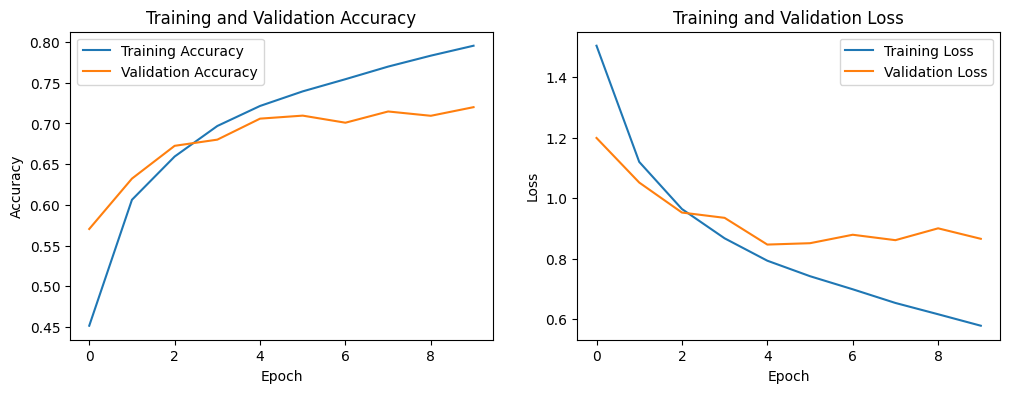

In [8]:
# Plot training and validation accuracy and loss over epochs
plt.figure(figsize=(12, 4))

# Plot training and validation accuracy
plt.subplot(1, 2, 1)  # 1 row, 2 columns, this is the first plot
plt.plot(history.history['accuracy'], label='Training Accuracy')  # Plot training accuracy
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')  # Plot validation accuracy
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()  # Add legend to differentiate the two lines

# Plot training and validation loss
plt.subplot(1, 2, 2)  # 1 row, 2 columns, this is the second plot
plt.plot(history.history['loss'], label='Training Loss')  # Plot training loss
plt.plot(history.history['val_loss'], label='Validation Loss')  # Plot validation loss
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()  # Add legend to differentiate the two lines

# Display the plots
plt.show()

**Step 9: Make Predictions on Test Data**

In [9]:
# Make predictions on the first 5 test images
predictions = model.predict(test_images[:5])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 940ms/step


**Step 10: Visualize Predictions**

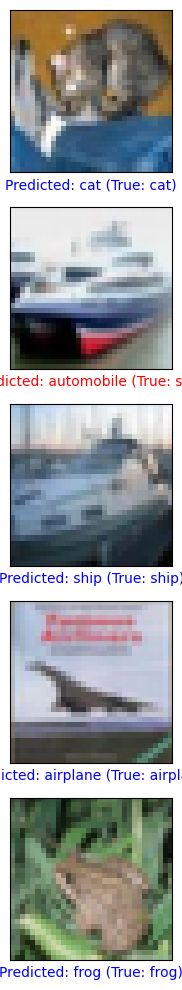

In [10]:
# Define a function to display images and predictions
def plot_image(i, predictions_array, true_label, img, class_names):
    predictions_array, true_label, img = predictions_array[i], true_label[i], img[i]
    plt.grid(False)  # Remove gridlines
    plt.xticks([])  # Remove x-axis ticks
    plt.yticks([])  # Remove y-axis ticks
    plt.imshow(img)  # Display the image

    # Get the predicted label
    predicted_label = np.argmax(predictions_array)

    # Set the color of the text based on whether the prediction is correct
    color = 'blue' if predicted_label == true_label else 'red'

    # Show the predicted and true labels in the image
    plt.xlabel(f"Predicted: {class_names[predicted_label]} (True: {class_names[true_label[0]]})", color=color)

# Visualize the first 5 test images with predictions
plt.figure(figsize=(5, 10))  # Create a figure for displaying 5 images in rows

for i in range(5):  # Loop through the first 5 images
    plt.subplot(5, 1, i + 1)  # 5 rows, 1 column, one image per row
    plot_image(i, predictions, test_labels, test_images, class_names)  # Call the plotting function

plt.tight_layout()  # Adjust layout to avoid overlap
plt.show()  # Show the plot

**Explanation**

**Purpose:** This tutorial shows how to build a CNN from start to finish, including preparing the data, training the model, checking its performance, and making predictions.
Dataset: It uses the CIFAR-10 dataset, which contains 60,000 color images of size 32×32 pixels divided into 10 classes.

**Main steps:** First, the images are normalized by dividing the pixel values by 255. Then, some sample images are displayed. After that, a CNN is created using convolution, pooling, and dense layers and trained for 10 epochs.

**Evaluation:** After training, the model is tested on the test data. Accuracy and loss graphs are also generated to see how the model performed during training.

**Prediction:** Finally, the model predicts the classes of some test images. The predicted labels are compared with the actual labels to see whether the model classified the images correctly.

**Overall:** In simple terms, the process is load images → prepare data → build CNN → train → evaluate → predict.

**Part 2: Assignment**

**Task Requirements**

The instructor's "Tasks" section asks for the following. Every requirement comes from that section; nothing else is added.

**Task 1: Experiment with different architectures**

Change the filter size.
Add more convolution layers or change the number of filters.
Add more fully connected layers or change the number of neurons.
Compare each modified model with the original.

**Task 2: Improve the accuracy of the model.**

**Task 3: Remove the overfitting/underfitting problem.**

**1: Import Libraries**

In [11]:
import tensorflow as tf  # For building and training the CNN
from tensorflow.keras import layers, models  # For creating layers and models
from tensorflow.keras.callbacks import EarlyStopping  # For stopping training when validation loss stops improving
import matplotlib.pyplot as plt  # For plotting images and accuracy/loss graphs
import numpy as np  # For numerical operations

**2: Load and Preprocess the CIFAR-10 Dataset**

In [12]:
# Load the CIFAR-10 dataset from TensorFlow datasets
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.cifar10.load_data()

# Normalize the pixel values from range [0, 255] to [0, 1]
train_images = train_images / 255.0
test_images = test_images / 255.0

# Class names for CIFAR-10
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# Dictionary to store the results of every model for the final comparison
results = {}

**3: Helper Functions (Train/Evaluate, Plot, Compare**

In [13]:
# Compile, train and evaluate a model (same settings as Part 1)
def train_and_evaluate(model, model_name, epochs=10, callbacks=None):
    # Compile the model using Adam optimizer and sparse categorical crossentropy as the loss function
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    # Train the model and validate on the test data
    history = model.fit(train_images, train_labels, epochs=epochs,
                        validation_data=(test_images, test_labels),
                        callbacks=callbacks)

    # Evaluate the model on the test set
    test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=0)
    print(f"{model_name} - Test accuracy: {test_acc}")

    # Save the results for the final comparison
    results[model_name] = (history, test_acc)
    return history


# Plot training and validation accuracy and loss (same as Step 8 of Part 1)
def plot_history(history, title):
    plt.figure(figsize=(12, 4))

    # Plot training and validation accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(title + ' - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot training and validation loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(title + ' - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()


# Print a table comparing all models trained so far
def print_comparison():
    print(f"{'Model':<40}{'Train Acc':<12}{'Val Acc':<12}{'Test Acc':<12}{'Gap (Train-Val)':<15}")
    for name, (history, test_acc) in results.items():
        train_acc = history.history['accuracy'][-1]   # Training accuracy at the last epoch
        val_acc = history.history['val_accuracy'][-1]  # Validation accuracy at the last epoch
        gap = train_acc - val_acc                      # A large gap means overfitting
        print(f"{name:<40}{train_acc:<12.4f}{val_acc:<12.4f}{test_acc:<12.4f}{gap:<15.4f}")


# Plot a bar chart of the test accuracy of all models
def plot_test_accuracy():
    names = list(results.keys())
    accs = [results[name][1] for name in names]
    plt.figure(figsize=(10, 4))
    plt.bar(names, accs)
    plt.ylabel('Test Accuracy')
    plt.title('Test Accuracy of All Models')
    plt.xticks(rotation=30, ha='right')
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()

**4: Original Model (Baseline from Part 1**

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.4480 - loss: 1.5149 - val_accuracy: 0.5627 - val_loss: 1.2205
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.5973 - loss: 1.1392 - val_accuracy: 0.6190 - val_loss: 1.0912
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6544 - loss: 0.9858 - val_accuracy: 0.6548 - val_loss: 0.9990
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6908 - loss: 0.8894 - val_accuracy: 0.6836 - val_loss: 0.9081
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.7111 - loss: 0.8258 - val_accuracy: 0.6837 - val_loss: 0.9184
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7324 - loss: 0.7711 - val_accuracy: 0.6948 - val_loss: 0.8784
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7482 - loss: 0.7184 - val_accuracy: 0.7120 - val_loss: 0.8566
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.7635 - loss: 0.6737 -

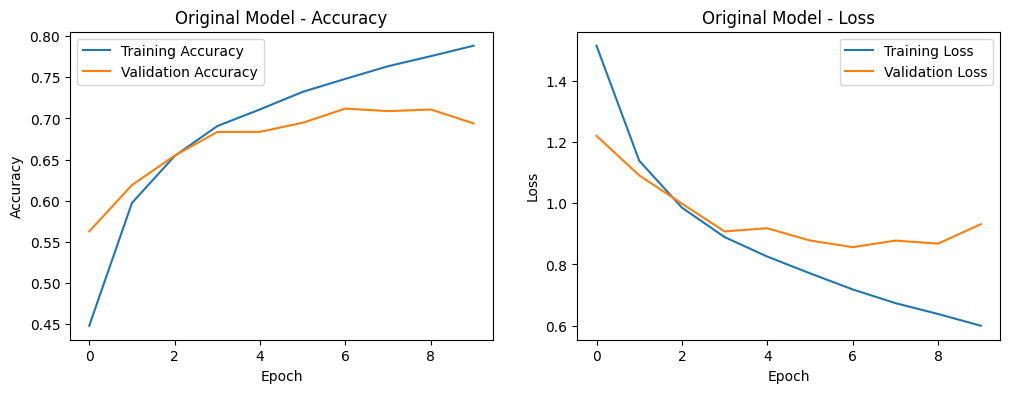

In [14]:
# Build the original CNN model from Part 1 (baseline)
model_original = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Display the model architecture summary
model_original.summary()

# Train for 10 epochs and evaluate
history_original = train_and_evaluate(model_original, 'Original (3x3, 32-64-64, Dense 64)', epochs=10)

# Plot the training and validation curves
plot_history(history_original, 'Original Model')

**5: Experiment 1, Different Filter Size (5x5)**

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 10, 10, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 128,202 (500.79 KB)

 Trainable params: 128,202 (500.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - accuracy: 0.4199 - loss: 1.5806 - val_accuracy: 0.5024 - val_loss: 1.3672
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.5535 - loss: 1.2529 - val_accuracy: 0.5439 - val_loss: 1.2639
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6070 - loss: 1.1086 - val_accuracy: 0.5850 - val_loss: 1.1962
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6481 - loss: 1.0050 - val_accuracy: 0.6155 - val_loss: 1.0904
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6735 - loss: 0.9224 - val_accuracy: 0.6601 - val_loss: 0.9798
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6987 - loss: 0.8544 - val_accuracy: 0.6698 - val_loss: 0.9558
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7173 - loss: 0.8028 - val_accuracy: 0.6600 - val_loss: 0.9836
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.7301 - loss: 0.7657 -

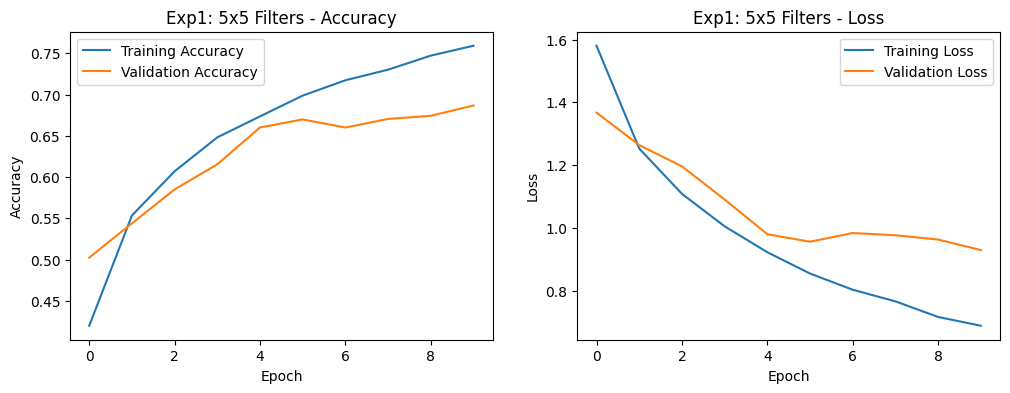

In [15]:
# Same architecture as the original but with 5x5 filters instead of 3x3
model_filter5 = models.Sequential([
    layers.Conv2D(32, (5, 5), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (5, 5), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),  # Kept 3x3 because the feature map is already small
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Display the model architecture summary
model_filter5.summary()

# Train for 10 epochs and evaluate
history_filter5 = train_and_evaluate(model_filter5, 'Exp1: Filter size 5x5', epochs=10)

# Plot the training and validation curves
plot_history(history_filter5, 'Exp1: 5x5 Filters')

**6: Experiment 2, More Convolution Layers and More Filters**

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 271,210 (1.03 MB)

 Trainable params: 271,210 (1.03 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 27s 13ms/step - accuracy: 0.4811 - loss: 1.4292 - val_accuracy: 0.6161 - val_loss: 1.0884
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.6715 - loss: 0.9297 - val_accuracy: 0.6614 - val_loss: 1.0138
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7366 - loss: 0.7551 - val_accuracy: 0.7182 - val_loss: 0.8237
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.7769 - loss: 0.6397 - val_accuracy: 0.7493 - val_loss: 0.7519
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8077 - loss: 0.5483 - val_accuracy: 0.7449 - val_loss: 0.7675
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8313 - loss: 0.4803 - val_accuracy: 0.7535 - val_loss: 0.7515
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8529 - loss: 0.4190 - val_accuracy: 0.7680 - val_loss: 0.7438
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8713 - loss: 0.

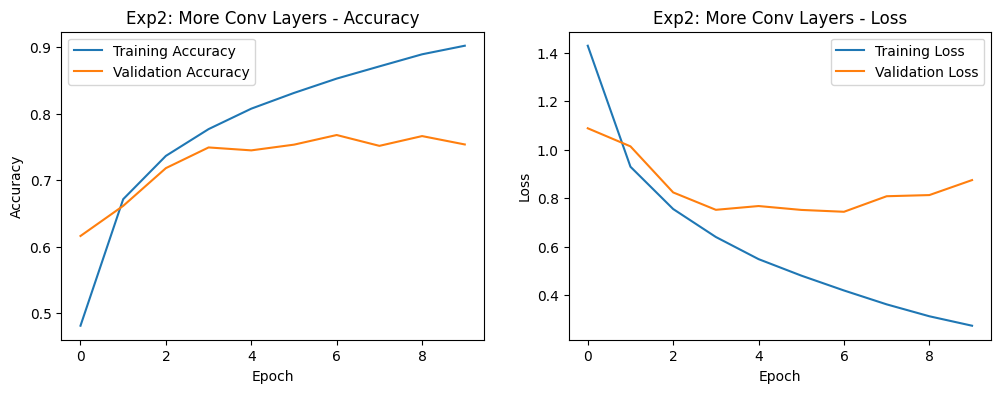

In [16]:
# More convolution layers and more filters (32 -> 64 -> 128), padding='same' keeps the image size
model_more_conv = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Display the model architecture summary
model_more_conv.summary()

# Train for 10 epochs and evaluate
history_more_conv = train_and_evaluate(model_more_conv, 'Exp2: More conv layers/filters', epochs=10)

# Plot the training and validation curves
plot_history(history_more_conv, 'Exp2: More Conv Layers')

**7: Experiment 3, More Fully Connected Layers and Neurons**

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 352,906 (1.35 MB)

 Trainable params: 352,906 (1.35 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.4577 - loss: 1.4780 - val_accuracy: 0.5499 - val_loss: 1.2733
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6127 - loss: 1.0866 - val_accuracy: 0.6483 - val_loss: 1.0067
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.6783 - loss: 0.9127 - val_accuracy: 0.6756 - val_loss: 0.9222
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7187 - loss: 0.7989 - val_accuracy: 0.6942 - val_loss: 0.9004
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7473 - loss: 0.7144 - val_accuracy: 0.7030 - val_loss: 0.8803
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.7744 - loss: 0.6366 - val_accuracy: 0.7119 - val_loss: 0.8513
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7981 - loss: 0.5689 - val_accuracy: 0.7134 - val_loss: 0.8817
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8199 - loss: 0.5047 

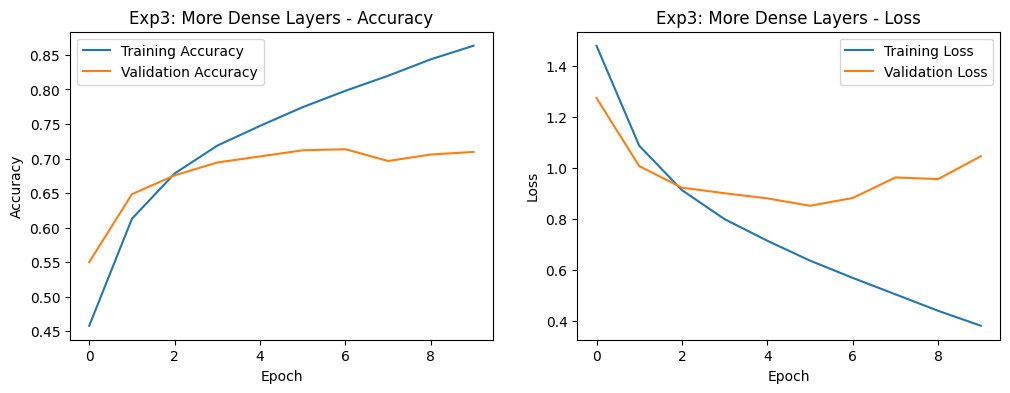

In [17]:
# Original convolution part, but with more fully connected layers and more neurons
model_more_dense = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),  # More neurons
    layers.Dense(128, activation='relu'),  # Additional fully connected layer
    layers.Dense(10, activation='softmax')
])

# Display the model architecture summary
model_more_dense.summary()

# Train for 10 epochs and evaluate
history_more_dense = train_and_evaluate(model_more_dense, 'Exp3: More dense layers/neurons', epochs=10)

# Plot the training and validation curves
plot_history(history_more_dense, 'Exp3: More Dense Layers')

**8: Compare the Modified Models with the Original**

Model                                   Train Acc   Val Acc     Test Acc    Gap (Train-Val)
Original (3x3, 32-64-64, Dense 64)      0.7884      0.6940      0.6940      0.0944         
Exp1: Filter size 5x5                   0.7591      0.6867      0.6867      0.0724         
Exp2: More conv layers/filters          0.9024      0.7538      0.7538      0.1486         
Exp3: More dense layers/neurons         0.8634      0.7095      0.7095      0.1539         


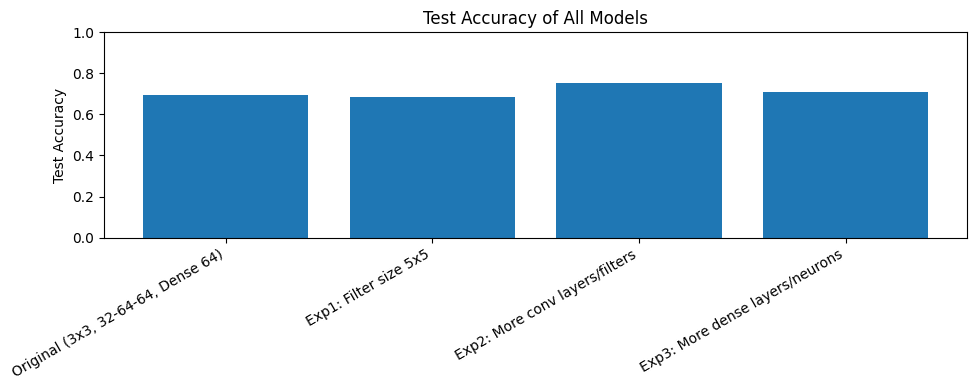

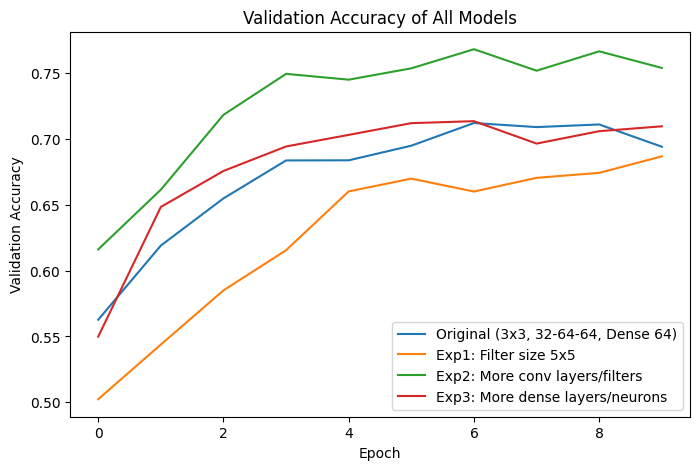

In [18]:
# Print the comparison table (a large Train-Val gap indicates overfitting)
print_comparison()

# Plot the test accuracy of all models
plot_test_accuracy()

# Plot the validation accuracy of all models on one graph
plt.figure(figsize=(8, 5))
for name, (history, test_acc) in results.items():
    plt.plot(history.history['val_accuracy'], label=name)
plt.title('Validation Accuracy of All Models')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.show()

**9: Improved Model (Tasks 2 and 3: Higher Accuracy and Less Overfitting)**

In [19]:
# Improved model:
# - More convolution layers and filters (more capacity, reduces underfitting)
# - Data augmentation (random flip/rotation/zoom, only active during training)
# - Dropout layers (randomly switch off neurons, reduces overfitting)
model_improved = models.Sequential([
    layers.Input(shape=(32, 32, 3)),

    # Data augmentation layers
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),

    # Block 1: 32 filters
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2),

    # Block 2: 64 filters
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),

    # Block 3: 128 filters
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.4),

    # Flatten and fully connected layers
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

# Display the model architecture summary
model_improved.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 32, 32, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 550,570 (2.10 MB)

 Trainable params: 550,570 (2.10 MB)

 Non-trainable params: 0 (0.00 B)

**10: Train the Improved Model (with Early Stopping)**

Epoch 1/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 25s 11ms/step - accuracy: 0.3384 - loss: 1.7882 - val_accuracy: 0.4762 - val_loss: 1.4561
Epoch 2/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.4829 - loss: 1.4293 - val_accuracy: 0.5755 - val_loss: 1.1797
Epoch 3/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.5376 - loss: 1.2994 - val_accuracy: 0.6052 - val_loss: 1.1128
Epoch 4/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.5688 - loss: 1.2212 - val_accuracy: 0.6273 - val_loss: 1.0551
Epoch 5/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.5876 - loss: 1.1691 - val_accuracy: 0.6642 - val_loss: 0.9711
Epoch 6/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.6073 - loss: 1.1207 - val_accuracy: 0.6555 - val_loss: 0.9671
Epoch 7/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.6182 - loss: 1.0956 - val_accuracy: 0.6619 - val_loss: 0.9601
Epoch 8/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.6318 -

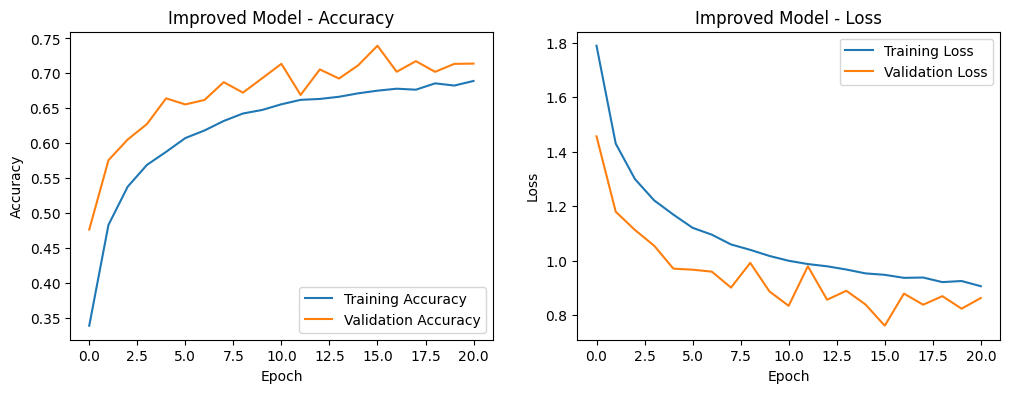

In [20]:
# Stop training when the validation loss has not improved for 5 epochs and keep the best weights
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train for up to 50 epochs (early stopping may stop sooner) and evaluate
history_improved = train_and_evaluate(model_improved, 'Improved (Aug + Dropout + Early Stop)',
                                      epochs=50, callbacks=[early_stop])

# Plot the training and validation curves
plot_history(history_improved, 'Improved Model')

**12: Predictions with the Improved Model**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step


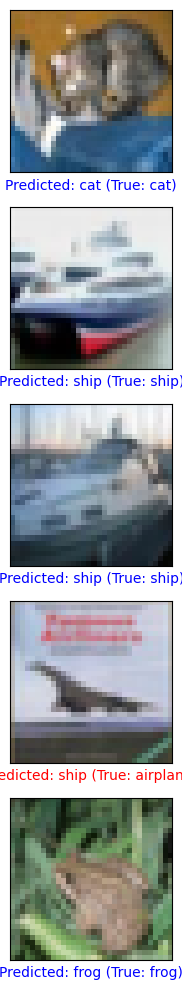

In [21]:
# Make predictions on the first 5 test images using the improved model
predictions = model_improved.predict(test_images[:5])

# Define a function to display images and predictions
def plot_image(i, predictions_array, true_label, img, class_names):
    predictions_array, true_label, img = predictions_array[i], true_label[i], img[i]
    plt.grid(False)  # Remove gridlines
    plt.xticks([])  # Remove x-axis ticks
    plt.yticks([])  # Remove y-axis ticks
    plt.imshow(img)  # Display the image

    # Get the predicted label
    predicted_label = np.argmax(predictions_array)

    # Set the color of the text based on whether the prediction is correct
    color = 'blue' if predicted_label == true_label else 'red'

    # Show the predicted and true labels in the image
    plt.xlabel(f"Predicted: {class_names[predicted_label]} (True: {class_names[true_label[0]]})", color=color)

# Visualize the first 5 test images with predictions
plt.figure(figsize=(5, 10))  # Create a figure for displaying 5 images in rows

for i in range(5):  # Loop through the first 5 images
    plt.subplot(5, 1, i + 1)  # 5 rows, 1 column, one image per row
    plot_image(i, predictions, test_labels, test_images, class_names)  # Call the plotting function

plt.tight_layout()  # Adjust layout to avoid overlap
plt.show()  # Show the plot